In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [3]:
# In case of errors, check if you are using the correct versions of the libraries. This notebook works on the following versions of libraries. Specify these versions if you get version related errors.
# TensorFlow version: 2.17.0
# Pandas version: 2.2.2
# NumPy version: 1.26.4
# Scikit-learn version: 1.5.2

# print("TensorFlow version:", tf.__version__)
# print("Pandas version:", pd.__version__)
# print("NumPy version:", np.__version__)
# print("Scikit-learn version:", sklearn.__version__)

### Part 1: Import the Housing data and do feature transformations

In [5]:
df= pd.read_csv('3.3.2 house-price-full-2-.csv')
df.head()

,bedrooms,sqft_living,price
0,3,1340,313000
1,5,3650,2384000
2,3,1930,342000
3,3,2000,420000
4,4,1940,550000


In [6]:
X = df.copy()
# Remove target
Y = X.pop('price')

# perform a scaler transform of the input data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# perform log transformation of target variable (For Sandeep: Is this needed?)
Y = np.log(Y)

why scalar transform is not used for the target variable ?

That's a great question! The reason we typically apply StandardScaler to features (like X) and a log transformation to the target variable (Y, in this case 'price') is due to their different roles and the objectives of transformation:

<ol>
<li><p><strong>Scaling Features (<code>X</code>) with <code>StandardScaler</code></strong>: Features are scaled to standardize their range. Many machine learning algorithms perform better when input numerical features are on a similar scale. This helps to prevent features with larger values from dominating the learning process, especially in algorithms like gradient descent, support vector machines, or neural networks.</p>
</li>
<li><p><strong>Transforming Target Variable (<code>Y</code>) with <code>np.log()</code></strong>: The target variable often has different transformation needs. For 'price', which is typically right-skewed (meaning there are more lower-priced houses and fewer very expensive ones), a logarithmic transformation (<code>np.log()</code>) is commonly used because it can:</p>
<ul>
<li><strong>Reduce Skewness</strong>: Make the distribution of the target variable more symmetrical and closer to a normal distribution.</li>
<li><strong>Stabilize Variance</strong>: Help make the variance more constant across different levels of the target variable.</li>
<li><strong>Improve Model Assumptions</strong>: Many regression models assume that the residuals (errors) are normally distributed and have constant variance. Log transformation can help meet these assumptions.</li>
<li><strong>Interpretability</strong>: When you predict <code>log(price)</code>, the errors often become a percentage rather than an absolute amount, which can be more intuitive for prices. After prediction, you can easily inverse-transform the results by taking the exponential (<code>np.exp()</code>) to get the actual price.</li>
</ul>
</li>
</ol>

In [ ]:
df_scaled = pd.DataFrame(X)
df_scaled

,0,1
0,-0.433198,-0.753258
1,1.675735,1.457330
2,-0.433198,-0.188649
3,-0.433198,-0.121661
4,0.621269,-0.179079
...,...,...
494,0.621269,0.873582
495,1.675735,2.299459
496,-0.433198,-0.724549
497,-0.433198,-0.179079


In [ ]:
Y

,price
0,12.653958
1,14.684290
2,12.742566
3,12.948010
4,13.217674
...,...
494,13.380102
495,13.764217
496,12.128111
497,12.721886


In [ ]:
#Taking 1 sample: x0,x1
x1, x2 = df_scaled.iloc[0]

In [ ]:
x = tf.constant([[x1,x2]], dtype=tf.float32)
x

<tf.Tensor: shape=(1, 2), dtype=float32, numpy=array([[-0.43319765, -0.7532575 ]], dtype=float32)>

### Part2: Forward Propagation with a single Neuron

The simplest way to describe a neural network is that we have some inputs , which get combined into an auxilliary variable . The auxilliary variable is passed through the activation function  and the result is the output.

Here is another image showing each step.

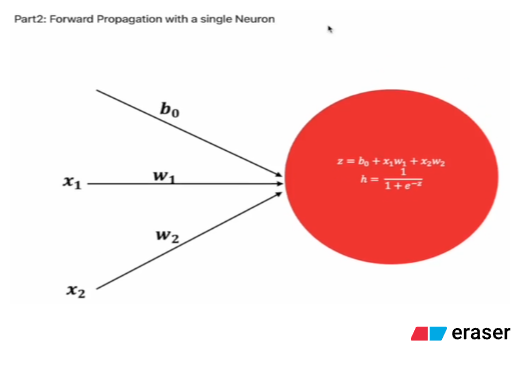

Notice that the inputs are linearly combined according to some weights  and a bias . This transformation is also sometimes called an affine transformation. The perceptron transforms the weighted inputs according to the rule of the activation function. For a single perceptron, the output  is just the output from the perceptron. The linear transformation and activation of the neuron occurs within a single layer of the network (shown in the dotted box).

Let's see what the single-layer, single neuron network give us. We have a couple of choices to make:

We must choose some weights and some biases
We must choose an activation function
For now, we will manually specify the weights and biases.

We choose a sigmoid activation function

In [ ]:
#weights
w1 = tf.Variable([0.2], dtype=tf.float32)
w2 = tf.Variable([0.15], dtype=tf.float32)
#bias
b = tf.Variable([0.1], dtype=tf.float32)

In [ ]:
#Cumulative input
z = b + w1*x1 +w2*x2
h = tf.math.sigmoid(z)
print("The output from the first neuron is",h)

The output from the first neuron is tf.Tensor([0.47511354], shape=(1,), dtype=float32)


### Part3: Forward Propagation with multiple neurons

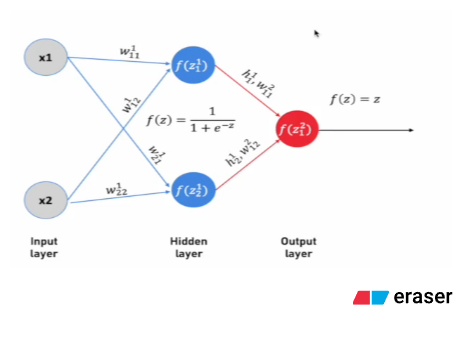

In [ ]:
## layer1 weights
# neuron1
b1 = tf.Variable([0.1])
w11 = tf.Variable([0.2])
w12 = tf.Variable([0.15])
#neuron2
b2 = tf.Variable([0.25])
w21 = tf.Variable([0.5])
w22 = tf.Variable([0.6])


In [ ]:
## forward pass
# neuron 1
z1 = b1+w11*x1+w12*x2
h1 = tf.math.sigmoid(z1)
print("The output from the first neuron is",h1)

The output from the first neuron is tf.Tensor([0.47511354], shape=(1,), dtype=float32)


In [ ]:
## forward pass
# neuron 2
z2 = b2+w21*x1+w22*x2
h2 = tf.math.sigmoid(z2)
print("The output from the second neuron is",h2)

The output from the second neuron is tf.Tensor([0.39686295], shape=(1,), dtype=float32)


In [ ]:
## layer2 weights
b1 = tf.Variable([0.4])
w11 = tf.Variable([0.3])
w12 = tf.Variable([0.2])

In [ ]:
## forward pass
# second layer
z1 = b1+w11*h1+w12*h2
h1 = z1
print("The output from the first neuron is",h1)

The output from the first neuron is tf.Tensor([0.62190664], shape=(1,), dtype=float32)


<div><span><p>You've observed correctly! In the previous code cell, for the second layer neuron's output <code>h1 = z1</code>, no sigmoid activation function was applied, unlike the neurons in the first layer.</p>
<p>This is a common practice in neural networks, especially when dealing with <strong>regression problems</strong> (like predicting house prices, or in this case, the log of house prices).</p>
<p>Here's why:</p>
<ol>
<li><p><strong>Regression Task</strong>: Our goal is to predict a continuous numerical value (the house price, after log transformation). If we were to apply a sigmoid function, the output of the neuron would be squashed into a range between 0 and 1. This would severely limit the range of predictions and make it impossible to predict the actual house prices.</p>
</li>
<li><p><strong>Linear Activation</strong>: When no explicit activation function is specified for an output layer in a regression network, it implicitly uses a <strong>linear activation function</strong>. A linear activation simply means that the output of the neuron is the weighted sum of its inputs plus the bias (<code>z1</code> in this case), allowing it to output any real number. This is exactly what's needed for regression tasks where the output can span a wide range of values.</p>
</li>
</ol>
</span></div>

In [ ]:
y_true = Y[0]
y_pred = h1.numpy()

In [ ]:
#loss
L = 0.5*(y_true - y_pred)**2
print("The MSE error is",L)

The MSE error is [72.38514]


## Part 4: Forward pass matrix multiplication

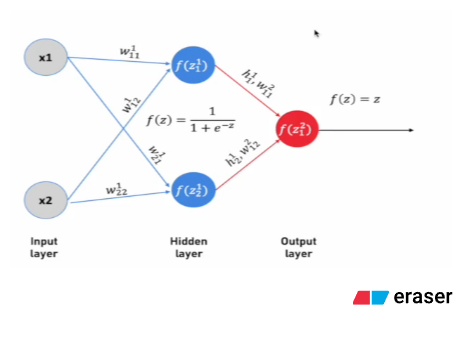


This network can be described as follows:

- Input vector = $X = (x1,x2)$
- Weight Matrix (hidden layer) = $$W^1 = \begin{bmatrix}
w^1_{11}&&w^1_{12}\\
w^1_{21}&&w^1_{22}\\
\end{bmatrix}
$$
*note the subscripts are being mapped to weights in the figure

- Bias/offset Matrix (hidden layer) = $$
B^1_0 = \begin{bmatrix}
b^1_{1}\\
b^1_{2}\\
\end{bmatrix}
$$

Now the forward pass for the hidden layer can be described as

$$W^1 \times X^T + B^1_0= Z^1 = \begin{bmatrix}
z^1_{1}\\
z^1_{2}\\
\end{bmatrix}
$$

Applying the activation function $f$ over the matrix $Z$ will complete the forward pass.

$$f(W^1 \times X^T + B^1_0)= f(Z^1) = f(\begin{bmatrix}
z^1_{1}\\
z^1_{2}\\
\end{bmatrix}) =
\begin{bmatrix}
f(z^1_{1})\\
f(z^1_{2})\\
\end{bmatrix}
=
\begin{bmatrix}
h^1_1\\
h^1_2\\
\end{bmatrix}
= H^1
$$

For the output layer:

- The weight matrix is $$W^2 = \begin{bmatrix}
w^2_{11}&&w^2_{12}\\
\end{bmatrix}
$$

- The bias/offset matrix is $$B^2_0 = \begin{bmatrix}
b^2_{1}\\
\end{bmatrix}
$$

Now the forward pass can be written as:


$$ B_0^2+W^2 \times H^1$$


In [ ]:
## layer 1 weights
W1 = tf.Variable([[0.2, 0.15],
                     [0.5, 0.6]], dtype=tf.float32)
## layer 1 bias
B1 = tf.Variable([[0.1],
                [0.25]], dtype=tf.float32)

In [ ]:
## layer 2 weights
W2 = tf.Variable([[0.3, 0.2]], dtype=tf.float32)
#bias
B2 = tf.Variable([0.4], dtype=tf.float32)

In [ ]:
## data
X = tf.constant([[x1,x2]], dtype=tf.float32)

In [ ]:
## forward pass layer 1
Z1 = tf.matmul(W1, tf.transpose(X)) + B1
H1 = tf.math.sigmoid(Z1)
print(H1)

tf.Tensor(
[[0.47511354]
 [0.39686295]], shape=(2, 1), dtype=float32)


In [ ]:
## forward pass layer 2
Z2 = tf.matmul(W2,H1)+B2

In [ ]:
Z2

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.62190664]], dtype=float32)>

In [ ]:
y_pred = Z2.numpy()
loss = 0.5*(y_true-y_pred)**2
print(loss)

[[72.38514]]


## Part5: Random Weight Initialization

![](multiple_neurons.png)

In [ ]:
def random_init_params():
    w1 = tf.Variable(tf.random.uniform((2, 2)))
    b1 = tf.Variable(tf.random.uniform((1, 2)))
    w2 = tf.Variable(tf.random.uniform((2, 1)))
    b2 = tf.Variable(tf.random.uniform((1, 1)))
    return w1,b1,w2,b2

In [ ]:
x = tf.constant([[x1,x2]], dtype=tf.float32)
y = Y[0]
w1,b1,w2,b2 = random_init_params()

In [ ]:
print(" the initial 1st layer weights are:\n",w1.numpy())
print("--------------------------------------------------")
print(" the initial 2nd layer weights are:\n",w2.numpy())
print("--------------------------------------------------")
print(" the initial 1st layer bias are:\n",b1.numpy())
print("--------------------------------------------------")
print(" the initial 2nd layer bias are:\n",b2.numpy())

 the initial 1st layer weights are:
 [[0.70953155 0.12170255]
 [0.09711456 0.57558334]]
--------------------------------------------------
 the initial 2nd layer weights are:
 [[0.3178439 ]
 [0.36558998]]
--------------------------------------------------
 the initial 1st layer bias are:
 [[0.35839927 0.08636701]]
--------------------------------------------------
 the initial 2nd layer bias are:
 [[0.659884]]


In [ ]:
def forward_prop(x, w1, b1, w2, b2):
    z1 = tf.matmul(x,w1) + b1
    h1 = tf.math.sigmoid(z1)
    z2 = tf.matmul(h1,w2) + b2
    h2 = z2
    return h2

In [ ]:
y_pred = forward_prop(x, w1, b1, w2, b2)
#loss
L = 0.5*(y - y_pred)**2
print("The MSE error is",L)

The MSE error is tf.Tensor([[68.33023]], shape=(1, 1), dtype=float32)


## Part6: Backpropagation

Find the value of x that minimises $y = x^2+4x$

Gradient descent update equation

$x_{new} := x_{old}-\eta\frac{dy}{dx}$

In [ ]:
x = tf.Variable(0.0) ## add gradient tape
lr = eta = 0.1

In [ ]:
with tf.GradientTape() as tape:
    y = x**2+4*x
grad = tape.gradient(y,x) ## dy/dx

In [ ]:
grad.numpy() #dy/dx = 2x+4, x=0 => dy/dx = 4

4.0

In [ ]:
x.assign_sub(lr*grad) ## x_new = x_old -lr*dy/dx

<tf.Variable 'UnreadVariable' shape=() dtype=float32, numpy=-0.4>

In [ ]:
x.numpy()

-0.4

In [ ]:
## full loop
x = tf.Variable(0.0) ## add gradient tape
lr = eta = 0.1
for i in range(10):
    with tf.GradientTape() as tape:
        y = x**2+4*x
    grad = tape.gradient(y,x)
    x.assign_sub(lr*grad)
    print(x.numpy())

-0.4
-0.72
-0.9760001
-1.1808001
-1.34464
-1.4757121
-1.5805696
-1.6644557
-1.7315645
-1.7852516



![](gradients.png)

In [ ]:
x = tf.constant([[x1,x2]], dtype=tf.float32)
y = Y[0]

def random_init_params():
    w1 = tf.Variable(tf.random.uniform((2, 2)))
    b1 = tf.Variable(tf.random.uniform((1, 2)))
    w2 = tf.Variable(tf.random.uniform((2, 1)))
    b2 = tf.Variable(tf.random.uniform((1, 1)))
    return w1,b1,w2,b2

def forward_prop(x, w1, b1, w2, b2):
    z1 = tf.matmul(x,w1) + b1
    h1 = tf.math.sigmoid(z1)
    z2 = tf.matmul(h1,w2) + b2
    h2 = z2
    return h2

In [ ]:
w1,b1,w2,b2 = random_init_params()

In [ ]:
with tf.GradientTape() as tape:
    y_pred = forward_prop(x,w1,b1,w2,b2)
    loss = 0.5*(y-y_pred)**2

In [ ]:
gw1, gb1, gw2, gb2 = tape.gradient(loss, [w1, b1, w2, b2])

In [ ]:
gw1

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[0.05097388, 0.9576167 ],
       [0.08863496, 1.6651336 ]], dtype=float32)>

In [ ]:
gb1

<tf.Tensor: shape=(1, 2), dtype=float32, numpy=array([[-0.11766887, -2.2105768 ]], dtype=float32)>

In [ ]:
gw2

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[-6.085041],
       [-5.407839]], dtype=float32)>

In [ ]:
gb2

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[-12.156635]], dtype=float32)>

In [ ]:
lr=0.01
print(f"Value of w1 before gradient update is {w1}")
w1.assign_sub(lr*gw1)
print(f"Value of w1 after gradient update is {w1}")

Value of w1 before gradient update is <tf.Variable 'Variable:0' shape=(2, 2) dtype=float32, numpy=
array([[0.5769646 , 0.4272014 ],
       [0.31190944, 0.45884228]], dtype=float32)>
Value of w1 after gradient update is <tf.Variable 'Variable:0' shape=(2, 2) dtype=float32, numpy=
array([[0.5764549 , 0.41762522],
       [0.3110231 , 0.44219095]], dtype=float32)>


In [ ]:
lr=0.01
print(f"Value of b1 before gradient update is {b1}")
b1.assign_sub(lr*gb1)
print(f"Value of w1 after gradient update is {b1}")

Value of b1 before gradient update is <tf.Variable 'Variable:0' shape=(1, 2) dtype=float32, numpy=array([[0.48710012, 0.30917442]], dtype=float32)>
Value of w1 after gradient update is <tf.Variable 'Variable:0' shape=(1, 2) dtype=float32, numpy=array([[0.4882768 , 0.33128017]], dtype=float32)>


In [ ]:
def train(x, y, w1, b1, w2, b2):
    y_true = y
    with tf.GradientTape() as g:
        y_pred = forward_prop(x, w1, b1, w2, b2)

        # loss
        loss = 0.5*(y_true - y_pred)** 2

    #Gradient calculation
    print("**************************************************")
    print("GRADIENTS")
    print("**************************************************")
    gw1, gb1, gw2, gb2 = g.gradient(loss, [w1, b1, w2, b2])
    print(" the gradient for 1st layer weights are:\n",gw1.numpy())
    print("--------------------------------------------------")
    print(" the gradient for 2nd layer weights are:\n",gw2.numpy())
    print("--------------------------------------------------")
    print(" the gradient for 1st layer bias are:\n",gb1.numpy())
    print("--------------------------------------------------")
    print(" the gradient for 2nd layer bias are:\n",gb2.numpy())
    print("--------------------------------------------------")

    # Gradient descent:
    lr=0.2
    w1.assign_sub(lr*gw1)
    b1.assign_sub(lr*gb1)
    w2.assign_sub(lr*gw2)
    b2.assign_sub(lr*gb2)
    print("**************************************************")
    print("NEW UPDATES")
    print("**************************************************")
    print(" the updated 1st layer weights are:\n",w1.numpy())
    print("--------------------------------------------------")
    print(" the updated 2nd layer weights are:\n",w2.numpy())
    print("--------------------------------------------------")
    print(" the updated 1st layer bias are:\n",b1.numpy())
    print("--------------------------------------------------")
    print(" the updated 2nd layer bias are:\n",b2.numpy())


    return w1, b1, w2, b2,loss

In [ ]:
w1,b1,w2,b2 = random_init_params()
w1, b1, w2, b2,loss = train(x, y, w1, b1, w2, b2)

**************************************************
GRADIENTS
**************************************************
 the gradient for 1st layer weights are:
 [[0.64991736 0.7497794 ]
 [1.1300964  1.3037397 ]]
--------------------------------------------------
 the gradient for 2nd layer weights are:
 [[-6.2255926]
 [-4.457245 ]]
--------------------------------------------------
 the gradient for 1st layer bias are:
 [[-1.5002791 -1.730802 ]]
--------------------------------------------------
 the gradient for 2nd layer bias are:
 [[-11.309267]]
--------------------------------------------------
**************************************************
NEW UPDATES
**************************************************
 the updated 1st layer weights are:
 [[0.30381602 0.52833676]
 [0.13821182 0.331776  ]]
--------------------------------------------------
 the updated 2nd layer weights are:
 [[1.7812213]
 [1.5323583]]
--------------------------------------------------
 the updated 1st layer bias are:


<div class="MuiBox-root css-lrle2m-container" data-testid="online-editor-player"><div class="text_component" data-testid="online-editor-content"><p>​In this session, you learnt how <strong>forward propagation</strong> and <strong>backpropagation</strong> occurs in neural networks and how the parameters are updated using the <strong>gradient descent</strong> algorithm.</p><p><br>You understood that the task is to <strong>minimise the loss function</strong> with respect to a large number of parameters and that it can be done efficiently using gradient descent. You then learnt how to derive the expressions for the gradient of loss with respect to the variables <img alt="Equation" data-latex="Z" src="https://latex.upgrad.com/render?formula=Z" style="vertical-align: middle;display: inline;">, <img alt="Equation" data-latex="W" src="https://latex.upgrad.com/render?formula=W" style="vertical-align: middle;display: inline;">,&nbsp;<img alt="Equation" data-latex="b" src="https://latex.upgrad.com/render?formula=b" style="vertical-align: middle;display: inline;"> and&nbsp;<img alt="Equation" data-latex="H" src="https://latex.upgrad.com/render?formula=H" style="vertical-align: middle;display: inline;"> of the various layers for a single data point. You then learnt how to repeatedly update the weights and biases of the network using these gradients.</p><p>Then, you explored the basics of an extensive library called TensorFlow to help build and train neural networks with ease and used it to implement the housing price prediction example. We hope you experiment with the code notebooks provided and explore and build more interesting neural networks!</p><p>In the next session, we will explore the implementation of neural networks using Keras and some commonly used best practices for training neural networks, dropouts and batch normalisation.&nbsp;</p></div></div>